# Trabalho 1: Analise de dados do IBGE sobre população, economia e desigualdade socioeconômica no Brasil

#### Disciplina: Mineração de Dados - 2026.2

Aluno: Leonardo Nascimento de Souza  
Matricula: 20240013771  
   
Aluno:  
Matricula:  


#### 0. Visualizando as tabelas (provavelmente vai sumir ou mudar)

In [1]:
import numpy as np
import pandas as pd
from dataset import API, Provider
from IPython.display import display

api: API = API()
dataset: list[pd.DataFrame] = []

# Armazena as tabelas extraídas da API em uma lista

dataset.append(api.query(Provider.IBGE, "PIB por município").rename(columns={"localidade": "Município", "2022": "PIB"}))
dataset.append(api.query(Provider.SIDRA, "Alfabetização por UF").rename(columns={"Unidade da Federação (Código)": "UF", "Valor": "Taxa de alfabetização"}))
# OUTRAS CONSULTAS...

       codigo                  localidade       2022
0     1100015  Alta Floresta D'Oeste - RO     919520
1     1100023              Ariquemes - RO    3809355
2     1100031                 Cabixi - RO     289783
3     1100049                 Cacoal - RO    3195489
4     1100056             Cerejeiras - RO     903099
...       ...                         ...        ...
5565  5222005             Vianópolis - GO     960672
5566  5222054         Vicentinópolis - GO     720444
5567  5222203               Vila Boa - GO     194803
5568  5222302          Vila Propício - GO     457512
5569  5300108               Brasília - DF  328789563

[5570 rows x 3 columns]
0  Unidade da Federação (Código) Valor
0                             11  95.1
1                             12  91.3
2                             13  95.1
3                             14  96.2
4                             15  92.5
5                             16  95.1
6                             17  92.8
7                          

Tratamento e normalização

In [2]:
dataset[0]["UF"] = dataset[0]["codigo"].astype(str).str[:2]
dataset[0]["PIB"] = pd.to_numeric(dataset[0]["PIB"], errors="coerce")
dataset[0] = dataset[0].groupby("UF", as_index=False)["PIB"].sum()

for ds in dataset:
    display(ds)

,UF,PIB
0,11,66795454
1,12,23676137
2,13,145140466
3,14,21095342
4,15,236141868
5,16,23614292
6,17,58208794
7,21,139789146
8,22,72834506
9,23,213600671


,UF,Taxa de alfabetização
0,11,95.1
1,12,91.3
2,13,95.1
3,14,96.2
4,15,92.5
5,16,95.1
6,17,92.8
7,21,88.0
8,22,85.2
9,23,87.9


Visualizar tabela da API (debug)

In [3]:
import requests
import pandas as pd

url = "https://apisidra.ibge.gov.br/values/t/10436/n3/all/v/2513/p/2022/c58/95253"

response = requests.get(url)
response.raise_for_status()

data = response.json()

df = pd.DataFrame(data)

#df

#### 2. Unificando os dados em um dataset

In [4]:
dados : pd.DataFrame = dataset[0]

for i in range(1, len(dataset)):
    dados = pd.merge(dados, dataset[i], how="inner", on=["UF"])

dados


,UF,PIB,Taxa de alfabetização
0,11,66795454,95.1
1,12,23676137,91.3
2,13,145140466,95.1
3,14,21095342,96.2
4,15,236141868,92.5
5,16,23614292,95.1
6,17,58208794,92.8
7,21,139789146,88.0
8,22,72834506,85.2
9,23,213600671,87.9


#### 3. Tratamento e integração

In [5]:
import geopandas as gpd

mapa = gpd.read_file("data/regioes/RG2017_regioesgeograficas2017.shp")

<AxesSubplot: >

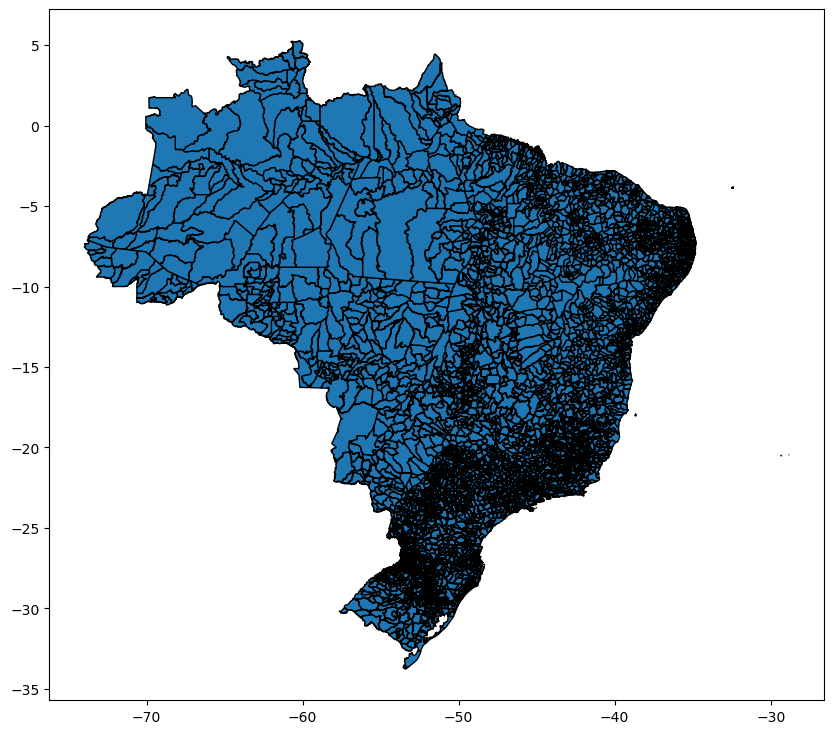

In [6]:
mapa.plot(
    figsize=(10, 10),
    edgecolor="black"
)